In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import GroupShuffleSplit
import shap

In [ ]:
# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Load dataset
df = pd.read_csv('/content/PhiUSIIL_Phishing_URL_Dataset.csv')
print("Dataset loaded successfully")

Dataset loaded successfully


In [ ]:
# Basic dataset information
print("Rows and columns:", df.shape)

Rows and columns: (235795, 55)


In [1]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:


NameError: name 'df' is not defined

In [ ]:
print("\nFirst 5 rows:")
display(df.head())


First 5 rows:


,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


In [ ]:
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  object 
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  object 
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   TLD                         235795 non-null  object 
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64  
 12  HasObfuscation              235795 non-null  int64

In [ ]:
print("\nBasic statistical summary:")
display(df.describe())


Basic statistical summary:


,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


In [ ]:
# Clean column names
df.columns = df.columns.str.strip()

In [ ]:
# Check missing values
print("\nMissing values in each column:")
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

print("\nTotal missing values:", df.isnull().sum().sum())


Missing values in each column:


,0



Total missing values: 0


In [ ]:
# Check duplicate rows
print("\nDuplicate rows before cleaning:", df.duplicated().sum())


Duplicate rows before cleaning: 0


In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())
print("Shape after removing duplicate rows:", df.shape)

Duplicate rows after cleaning: 0
Shape after removing duplicate rows: (235795, 55)


In [ ]:
# Check duplicate URLs
print("\nDuplicate URLs:", df['URL'].duplicated().sum())


Duplicate URLs: 425


In [ ]:
# Remove duplicate URLs to reduce data leakage
df = df.drop_duplicates(subset='URL', keep='first')

print("Duplicate URLs after cleaning:", df['URL'].duplicated().sum())
print("Shape after removing duplicate URLs:", df.shape)

Duplicate URLs after cleaning: 0
Shape after removing duplicate URLs: (235370, 55)


In [ ]:
# Check target column
print("\nTarget column values:")
print(df['label'].value_counts())

print("\nTarget column percentage:")
print(df['label'].value_counts(normalize=True) * 100)


Target column values:
label
1    134850
0    100520
Name: count, dtype: int64

Target column percentage:
label
1    57.292773
0    42.707227
Name: proportion, dtype: float64


In [ ]:
# Separate numeric and text columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
text_columns = df.select_dtypes(include=['object']).columns

print("\nNumber of numeric columns:", len(numeric_columns))
print("Number of text columns:", len(text_columns))

print("\nText columns:")
print(text_columns.tolist())


Number of numeric columns: 51
Number of text columns: 4

Text columns:
['URL', 'Domain', 'TLD', 'Title']


In [ ]:
# Fill missing numeric values if any exist
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

# Fill missing text values if any exist
df[text_columns] = df[text_columns].fillna("Unknown")

print("\nTotal missing values after cleaning:", df.isnull().sum().sum())


Total missing values after cleaning: 0


In [ ]:
# Class distribution table
class_distribution = df['label'].value_counts().sort_index()
class_percentage = df['label'].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    'Class': class_distribution.index,
    'Count': class_distribution.values,
    'Percentage': class_percentage.values
})

print("\nClass distribution summary:")
display(class_summary)


Class distribution summary:


,Class,Count,Percentage
0,0,100520,42.707227
1,1,134850,57.292773


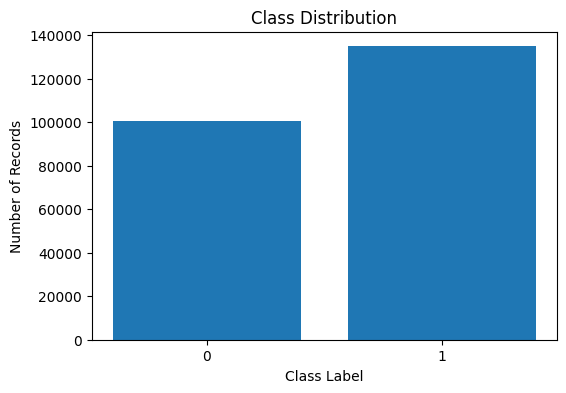

In [ ]:
# Class distribution chart
plt.figure(figsize=(6, 4))
plt.bar(class_summary['Class'].astype(str), class_summary['Count'])
plt.title('Class Distribution')
plt.xlabel('Class Label')
plt.ylabel('Number of Records')
plt.show()

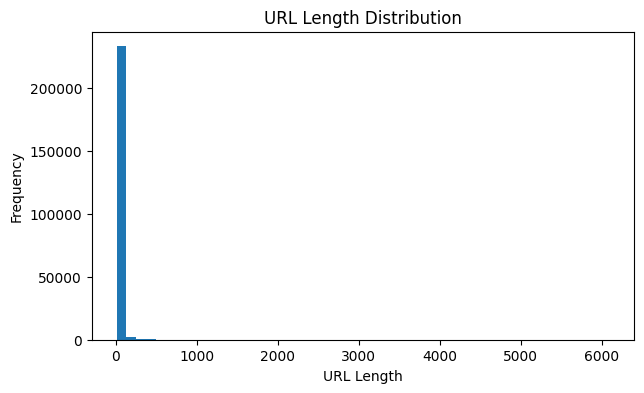

In [ ]:
# URL length distribution
plt.figure(figsize=(7, 4))
plt.hist(df['URLLength'], bins=50)
plt.title('URL Length Distribution')
plt.xlabel('URL Length')
plt.ylabel('Frequency')
plt.show()

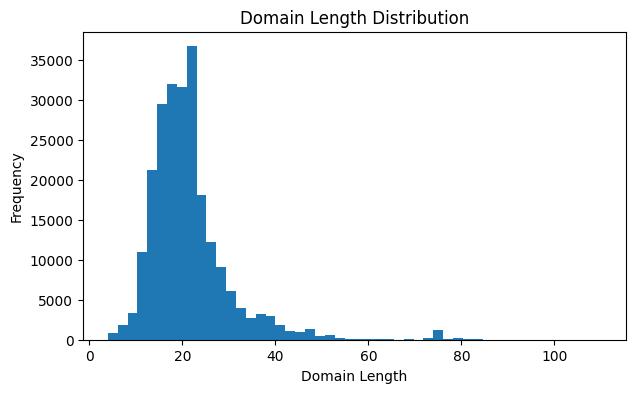

In [ ]:
# Domain length distribution
plt.figure(figsize=(7, 4))
plt.hist(df['DomainLength'], bins=50)
plt.title('Domain Length Distribution')
plt.xlabel('Domain Length')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# HTTPS distribution by class
https_summary = pd.crosstab(df['label'], df['IsHTTPS'])

print("\nHTTPS distribution by class:")
display(https_summary)


HTTPS distribution by class:


IsHTTPS,0,1
label,,
0,51142,49378
1,0,134850


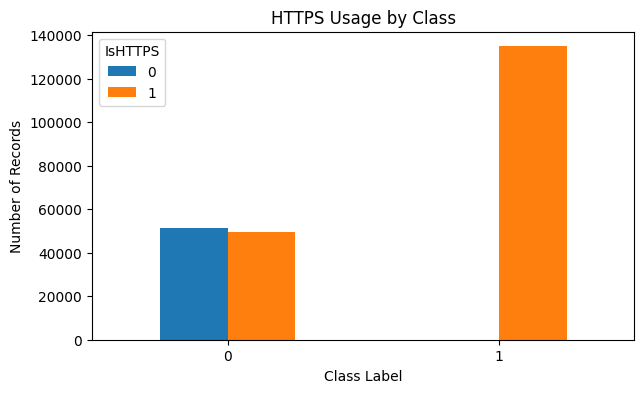

In [ ]:
https_summary.plot(kind='bar', figsize=(7, 4))
plt.title('HTTPS Usage by Class')
plt.xlabel('Class Label')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Obfuscation distribution by class
obfuscation_summary = pd.crosstab(df['label'], df['HasObfuscation'])

print("\nObfuscation distribution by class:")
display(obfuscation_summary)


Obfuscation distribution by class:


HasObfuscation,0,1
label,,
0,100037,483
1,134850,0


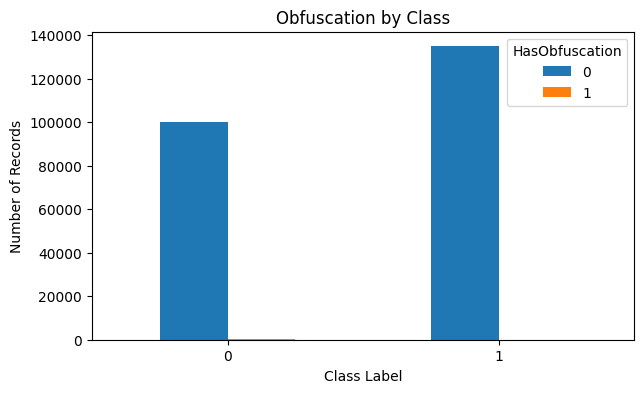

In [ ]:
obfuscation_summary.plot(kind='bar', figsize=(7, 4))
plt.title('Obfuscation by Class')
plt.xlabel('Class Label')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Correlation with target
correlation_with_label = df[numeric_columns].corr()['label'].sort_values(ascending=False)

print("\nTop positive correlations with label:")
display(correlation_with_label.head(10))

print("\nTop negative correlations with label:")
display(correlation_with_label.tail(10))


Top positive correlations with label:


,label
label,1.000000
URLSimilarityIndex,0.860342
HasSocialNet,0.783882
HasCopyrightInfo,0.743197
HasDescription,0.690011
IsHTTPS,0.610253
DomainTitleMatchScore,0.584204
HasSubmitButton,0.578816
IsResponsive,0.548977
URLTitleMatchScore,0.538844



Top negative correlations with label:


,label
TLDLength,-0.078973
NoOfQMarkInURL,-0.176027
NoOfDegitsInURL,-0.177755
URLLength,-0.233060
NoOfLettersInURL,-0.257626
DomainLength,-0.282643
NoOfOtherSpecialCharsInURL,-0.358268
LetterRatioInURL,-0.366970
DegitRatioInURL,-0.431896
SpacialCharRatioInURL,-0.533003


In [ ]:
# Keep a copy of the cleaned dataset
data = df.copy()

In [ ]:
# Remove text columns for the first simple modelling stage
data = data.drop(columns=['URL', 'Domain', 'TLD', 'Title'])

In [ ]:
# Check the remaining columns
print("Dataset shape after removing text columns:", data.shape)
print("\nRemaining columns:")
print(data.columns.tolist())

Dataset shape after removing text columns: (235370, 51)

Remaining columns:
['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


In [ ]:
# Separate input features and target label
X = data.drop(columns=['label'])
y = data['label']

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (235370, 50)
Target shape: (235370,)


In [ ]:
# Check class balance before splitting
print("\nClass balance before splitting:")
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)


Class balance before splitting:
label
1    134850
0    100520
Name: count, dtype: int64
label
1    57.292773
0    42.707227
Name: proportion, dtype: float64


In [ ]:
# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("\nTraining feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)


Training feature shape: (188296, 50)
Testing feature shape: (47074, 50)
Training target shape: (188296,)
Testing target shape: (47074,)


In [ ]:
# Check class balance after splitting
print("\nTraining class distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting class distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)


Training class distribution:
label
1    107880
0     80416
Name: count, dtype: int64
label
1    57.292773
0    42.707227
Name: proportion, dtype: float64

Testing class distribution:
label
1    26970
0    20104
Name: count, dtype: int64
label
1    57.292773
0    42.707227
Name: proportion, dtype: float64


In [ ]:
# Scale numeric features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Convert scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nScaled training data preview:")
display(X_train_scaled.head())

print("\nScaled testing data preview:")
display(X_test_scaled.head())


Scaled training data preview:


,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
0,1.339071,0.170306,-0.052674,-2.328547,-0.746760,1.043680,-1.034480,0.392475,1.390263,-0.045499,...,-0.382384,-0.557762,-0.154772,-0.976453,-0.340123,-0.076468,-0.447097,-0.390412,-0.129514,-0.320450
1,-0.131048,0.060689,-0.052674,0.742656,0.713457,-0.978492,0.048077,-1.273587,-0.273888,-0.045499,...,-0.382384,-0.557762,-0.154772,1.024115,0.026237,-0.052537,-0.023178,-0.108540,-0.129514,-0.014654
2,-0.364401,-1.035477,-0.052674,0.275084,0.713457,-0.882020,-1.259477,0.392475,-0.273888,-0.045499,...,-0.382384,-0.557762,-0.154772,-0.976453,-0.340123,-0.076468,-0.447097,-0.390412,-0.129514,-0.320450
3,-0.014372,0.608772,-0.052674,0.742656,0.713457,1.043680,0.483783,0.392475,-0.273888,-0.045499,...,2.615174,-0.557762,-0.154772,-0.976453,-0.026100,-0.040571,-0.150354,1.312814,-0.129514,2.015308
4,134.396580,2.253021,-0.052674,-2.704812,-2.328661,-1.030907,-2.268733,0.392475,1.390263,-0.045499,...,-0.382384,-0.557762,-0.154772,-0.976453,-0.340123,-0.076468,-0.362313,-0.390412,-0.129514,-0.320450



Scaled testing data preview:


,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
0,0.055633,0.828005,-0.052674,-1.411981,0.158575,-1.028758,-3.100447,0.392475,-0.273888,-0.045499,...,-0.382384,-0.557762,-0.154772,-0.976453,-0.340123,-0.076468,-0.447097,-0.390412,-0.129514,-0.300931
1,-0.247725,-0.487394,-0.052674,0.742656,-0.827883,1.043680,0.651302,0.392475,-0.273888,-0.045499,...,-0.382384,-0.557762,-0.154772,-0.976453,0.078574,-0.064503,0.019214,0.311269,0.249524,0.460305
2,0.008963,0.718389,-0.052674,0.742656,0.713457,1.043680,1.247336,0.392475,-0.273888,-0.045499,...,-0.382384,-0.557762,-0.154772,1.024115,-0.091522,0.174810,2.308381,-0.156519,-0.021217,0.030890
3,-0.294395,-0.597010,-0.052674,-0.312378,-1.341663,-0.921230,0.090759,-1.273587,-0.273888,-0.045499,...,-0.382384,-0.557762,-0.154772,-0.976453,-0.340123,-0.076468,-0.447097,-0.390412,-0.129514,-0.320450
4,-0.177719,-0.048927,-0.052674,-0.463299,0.713457,-1.034005,0.672322,3.724599,-0.273888,-0.045499,...,-0.382384,-0.557762,-0.154772,-0.976453,-0.340123,-0.076468,-0.447097,-0.390412,-0.129514,-0.320450


In [ ]:
# Train Logistic Regression
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression completed")

Logistic Regression completed


In [ ]:
# Train Decision Tree
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_scaled, y_train)

decision_tree_pred = decision_tree_model.predict(X_test_scaled)
decision_tree_prob = decision_tree_model.predict_proba(X_test_scaled)[:, 1]

print("Decision Tree completed")

Decision Tree completed


In [ ]:
# Train Random Forest
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
random_forest_model.fit(X_train_scaled, y_train)

random_forest_pred = random_forest_model.predict(X_test_scaled)
random_forest_prob = random_forest_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest completed")

Random Forest completed


In [ ]:
# Train Linear SVM
svm_model = LinearSVC(random_state=42, max_iter=5000)
svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)
svm_score = svm_model.decision_function(X_test_scaled)

print("Linear SVM completed")

Linear SVM completed


In [ ]:
# Create results table
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Linear SVM'
    ],
    'Accuracy': [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, decision_tree_pred),
        accuracy_score(y_test, random_forest_pred),
        accuracy_score(y_test, svm_pred)
    ],
    'Precision Weighted': [
        precision_score(y_test, logistic_pred, average='weighted'),
        precision_score(y_test, decision_tree_pred, average='weighted'),
        precision_score(y_test, random_forest_pred, average='weighted'),
        precision_score(y_test, svm_pred, average='weighted')
    ],
    'Recall Weighted': [
        recall_score(y_test, logistic_pred, average='weighted'),
        recall_score(y_test, decision_tree_pred, average='weighted'),
        recall_score(y_test, random_forest_pred, average='weighted'),
        recall_score(y_test, svm_pred, average='weighted')
    ],
    'F1 Weighted': [
        f1_score(y_test, logistic_pred, average='weighted'),
        f1_score(y_test, decision_tree_pred, average='weighted'),
        f1_score(y_test, random_forest_pred, average='weighted'),
        f1_score(y_test, svm_pred, average='weighted')
    ],
    'ROC AUC': [
        roc_auc_score(y_test, logistic_prob),
        roc_auc_score(y_test, decision_tree_prob),
        roc_auc_score(y_test, random_forest_prob),
        roc_auc_score(y_test, svm_score)
    ],
    'Phishing Recall Class 0': [
        recall_score(y_test, logistic_pred, pos_label=0),
        recall_score(y_test, decision_tree_pred, pos_label=0),
        recall_score(y_test, random_forest_pred, pos_label=0),
        recall_score(y_test, svm_pred, pos_label=0)
    ],
    'Phishing F1 Class 0': [
        f1_score(y_test, logistic_pred, pos_label=0),
        f1_score(y_test, decision_tree_pred, pos_label=0),
        f1_score(y_test, random_forest_pred, pos_label=0),
        f1_score(y_test, svm_pred, pos_label=0)
    ]
})

In [ ]:
print("\nBaseline model comparison:")
display(results)


Baseline model comparison:


,Model,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,ROC AUC,Phishing Recall Class 0,Phishing F1 Class 0
0,Logistic Regression,0.999936,0.999936,0.999936,0.999936,1.0,0.999851,0.999925
1,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
3,Linear SVM,0.999958,0.999958,0.999958,0.999958,1.0,0.999901,0.999950



Logistic Regression classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20104
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



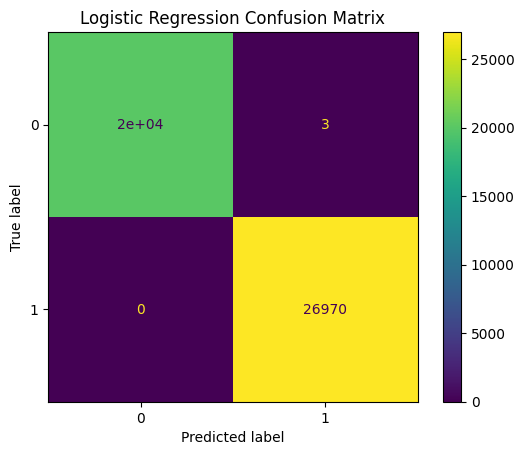

In [ ]:
# Show detailed report for Logistic Regression
print("\nLogistic Regression classification report:")
print(classification_report(y_test, logistic_pred))

cm = confusion_matrix(y_test, logistic_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()


Decision Tree classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20104
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



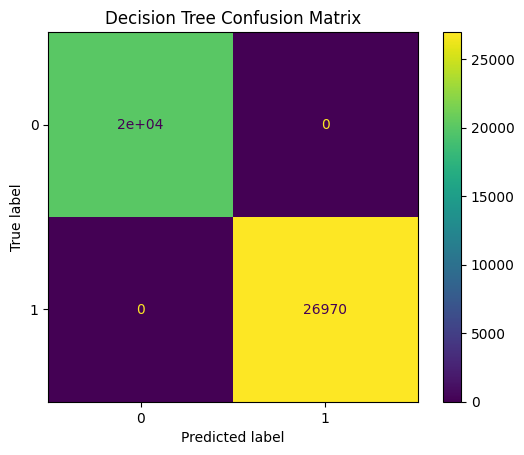

In [ ]:
# Show detailed report for Decision Tree
print("\nDecision Tree classification report:")
print(classification_report(y_test, decision_tree_pred))

cm = confusion_matrix(y_test, decision_tree_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()


Random Forest classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20104
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



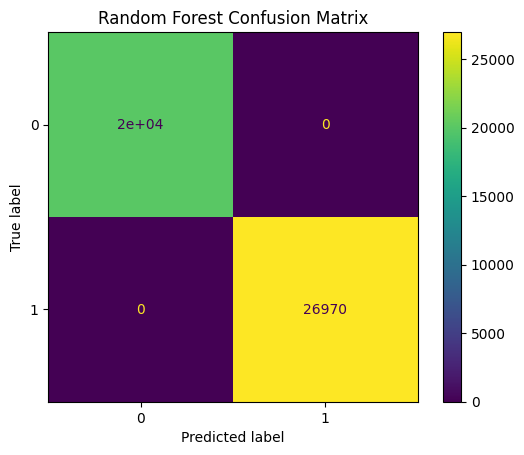

In [ ]:
# Show detailed report for Random Forest
print("\nRandom Forest classification report:")
print(classification_report(y_test, random_forest_pred))

cm = confusion_matrix(y_test, random_forest_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()


Linear SVM classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20104
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



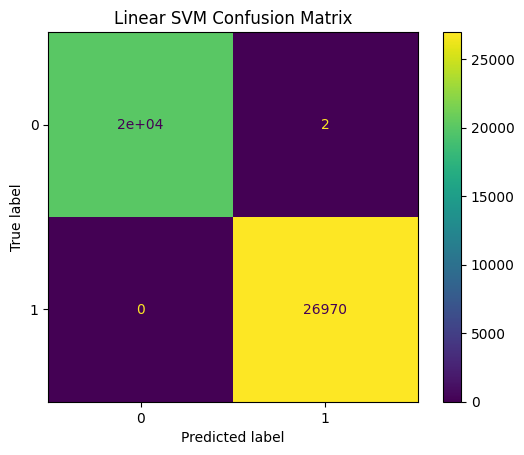

In [ ]:
# Show detailed report for Linear SVM
print("\nLinear SVM classification report:")
print(classification_report(y_test, svm_pred))

cm = confusion_matrix(y_test, svm_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Linear SVM Confusion Matrix")
plt.show()

In [ ]:
# Build ANN/DNN model
ann_model = Sequential()

ann_model.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))
ann_model.add(BatchNormalization())
ann_model.add(Dropout(0.30))

ann_model.add(Dense(64, activation='relu'))
ann_model.add(BatchNormalization())
ann_model.add(Dropout(0.20))

ann_model.add(Dense(32, activation='relu'))
ann_model.add(Dropout(0.10))

ann_model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile model
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show model structure
ann_model.summary()

# Stop training when validation loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,665 (69.00 KB)

 Trainable params: 17,281 (67.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# Train ANN/DNN model
history = ann_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
589/589 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9936 - loss: 0.0195 - val_accuracy: 0.9998 - val_loss: 6.2878e-04
Epoch 2/20
589/589 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9997 - loss: 9.6118e-04 - val_accuracy: 0.9999 - val_loss: 5.7386e-04
Epoch 3/20
589/589 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9998 - loss: 7.0840e-04 - val_accuracy: 0.9999 - val_loss: 4.7978e-04
Epoch 4/20
589/589 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9998 - loss: 5.0896e-04 - val_accuracy: 0.9999 - val_loss: 2.8395e-04
Epoch 5/20
589/589 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9999 - loss: 3.6752e-04 - val_accuracy: 0.9998 - val_loss: 6.7523e-04
Epoch 6/20
589/589 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9999 - loss: 3.5419e-04 - val_accuracy: 0.9999 - val_loss: 5.0771e-04
Epoch 7/20
589/589 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9999 - loss: 2.6556e-04 - val_accuracy: 0.9999 - val_loss: 4.4661e-04


In [ ]:
# Predict on test data
ann_prob = ann_model.predict(X_test_scaled)
ann_prob = ann_prob.ravel()

ann_pred = (ann_prob >= 0.5).astype(int)

1472/1472 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [ ]:
# Calculate ANN/DNN results
ann_results = pd.DataFrame({
    'Model': ['ANN/DNN'],
    'Accuracy': [accuracy_score(y_test, ann_pred)],
    'Precision Weighted': [precision_score(y_test, ann_pred, average='weighted')],
    'Recall Weighted': [recall_score(y_test, ann_pred, average='weighted')],
    'F1 Weighted': [f1_score(y_test, ann_pred, average='weighted')],
    'ROC AUC': [roc_auc_score(y_test, ann_prob)],
    'Phishing Recall Class 0': [recall_score(y_test, ann_pred, pos_label=0)],
    'Phishing F1 Class 0': [f1_score(y_test, ann_pred, pos_label=0)]
})

print("\nANN/DNN result:")
display(ann_results)


ANN/DNN result:


,Model,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,ROC AUC,Phishing Recall Class 0,Phishing F1 Class 0
0,ANN/DNN,0.999958,0.999958,0.999958,0.999958,1.0,0.999901,0.99995


In [ ]:
# Detailed ANN/DNN report
print("\nANN/DNN classification report:")
print(classification_report(y_test, ann_pred))


ANN/DNN classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20104
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



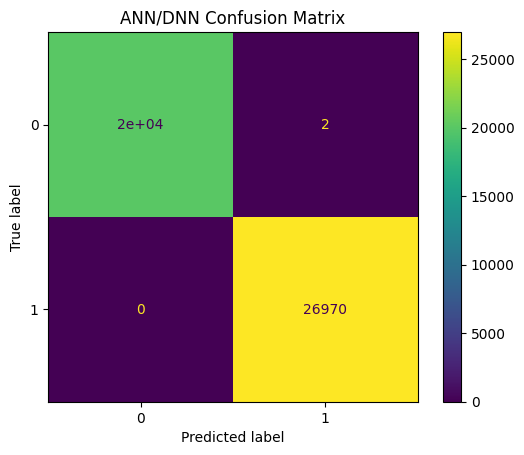

In [ ]:
# ANN/DNN confusion matrix
cm = confusion_matrix(y_test, ann_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("ANN/DNN Confusion Matrix")
plt.show()

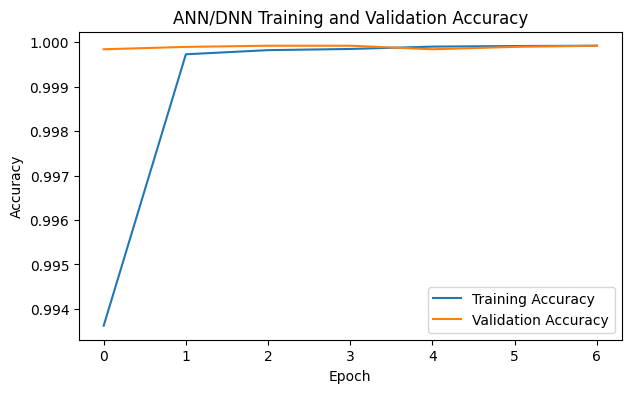

In [ ]:
# Training accuracy curve
plt.figure(figsize=(7, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN/DNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

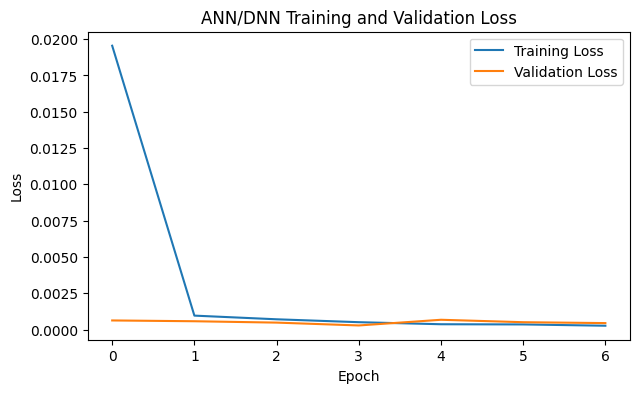

In [ ]:
# Training loss curve
plt.figure(figsize=(7, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('ANN/DNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Compare ANN/DNN with previous baseline models
all_model_results = pd.concat([results, ann_results], ignore_index=True)

print("\nAll model comparison:")
display(all_model_results)


All model comparison:


,Model,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,ROC AUC,Phishing Recall Class 0,Phishing F1 Class 0
0,Logistic Regression,0.999936,0.999936,0.999936,0.999936,1.0,0.999851,0.999925
1,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
3,Linear SVM,0.999958,0.999958,0.999958,0.999958,1.0,0.999901,0.999950
4,ANN/DNN,0.999958,0.999958,0.999958,0.999958,1.0,0.999901,0.999950


In [ ]:
# Keep a fresh copy of cleaned dataset
zero_hour_data = df.copy()

In [ ]:
# Use domains as groups for unseen-domain testing
groups = zero_hour_data['Domain']

# Remove text columns
zero_hour_numeric = zero_hour_data.drop(columns=['URL', 'Domain', 'TLD', 'Title'])

# Separate features and target
X_zero = zero_hour_numeric.drop(columns=['label'])
y_zero = zero_hour_numeric['label']

In [ ]:
# Split by domain so test domains are unseen during training
group_split = GroupShuffleSplit(test_size=0.20, n_splits=1, random_state=42)

for train_index, test_index in group_split.split(X_zero, y_zero, groups):
    X_zero_train = X_zero.iloc[train_index]
    X_zero_test = X_zero.iloc[test_index]
    y_zero_train = y_zero.iloc[train_index]
    y_zero_test = y_zero.iloc[test_index]
    train_domains = groups.iloc[train_index]
    test_domains = groups.iloc[test_index]

In [ ]:
# Check unseen-domain separation
common_domains = set(train_domains).intersection(set(test_domains))

print("Unseen-domain split completed")
print("Common domains between training and testing:", len(common_domains))

print("\nTraining shape:", X_zero_train.shape)
print("Testing shape:", X_zero_test.shape)

print("\nTraining class distribution:")
print(y_zero_train.value_counts())
print(y_zero_train.value_counts(normalize=True) * 100)

print("\nTesting class distribution:")
print(y_zero_test.value_counts())
print(y_zero_test.value_counts(normalize=True) * 100)

Unseen-domain split completed
Common domains between training and testing: 0

Training shape: (188738, 50)
Testing shape: (46632, 50)

Training class distribution:
label
1    107927
0     80811
Name: count, dtype: int64
label
1    57.183503
0    42.816497
Name: proportion, dtype: float64

Testing class distribution:
label
1    26923
0    19709
Name: count, dtype: int64
label
1    57.735032
0    42.264968
Name: proportion, dtype: float64


In [ ]:
# Scale features
zero_scaler = StandardScaler()

X_zero_train_scaled = zero_scaler.fit_transform(X_zero_train)
X_zero_test_scaled = zero_scaler.transform(X_zero_test)

X_zero_train_scaled = pd.DataFrame(X_zero_train_scaled, columns=X_zero.columns)
X_zero_test_scaled = pd.DataFrame(X_zero_test_scaled, columns=X_zero.columns)

In [ ]:
# Train Logistic Regression on unseen-domain split
zero_logistic_model = LogisticRegression(max_iter=1000, random_state=42)
zero_logistic_model.fit(X_zero_train_scaled, y_zero_train)

zero_logistic_pred = zero_logistic_model.predict(X_zero_test_scaled)
zero_logistic_prob = zero_logistic_model.predict_proba(X_zero_test_scaled)[:, 1]

print("\nUnseen-domain Logistic Regression completed")


Unseen-domain Logistic Regression completed


In [ ]:
# Train Random Forest on unseen-domain split
zero_rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
zero_rf_model.fit(X_zero_train_scaled, y_zero_train)

zero_rf_pred = zero_rf_model.predict(X_zero_test_scaled)
zero_rf_prob = zero_rf_model.predict_proba(X_zero_test_scaled)[:, 1]

print("Unseen-domain Random Forest completed")

Unseen-domain Random Forest completed


In [ ]:
# Create unseen-domain results table
zero_hour_results = pd.DataFrame({
    'Model': [
        'Logistic Regression Unseen-Domain',
        'Random Forest Unseen-Domain'
    ],
    'Accuracy': [
        accuracy_score(y_zero_test, zero_logistic_pred),
        accuracy_score(y_zero_test, zero_rf_pred)
    ],
    'Precision Weighted': [
        precision_score(y_zero_test, zero_logistic_pred, average='weighted'),
        precision_score(y_zero_test, zero_rf_pred, average='weighted')
    ],
    'Recall Weighted': [
        recall_score(y_zero_test, zero_logistic_pred, average='weighted'),
        recall_score(y_zero_test, zero_rf_pred, average='weighted')
    ],
    'F1 Weighted': [
        f1_score(y_zero_test, zero_logistic_pred, average='weighted'),
        f1_score(y_zero_test, zero_rf_pred, average='weighted')
    ],
    'ROC AUC': [
        roc_auc_score(y_zero_test, zero_logistic_prob),
        roc_auc_score(y_zero_test, zero_rf_prob)
    ],
    'Phishing Recall Class 0': [
        recall_score(y_zero_test, zero_logistic_pred, pos_label=0),
        recall_score(y_zero_test, zero_rf_pred, pos_label=0)
    ],
    'Phishing F1 Class 0': [
        f1_score(y_zero_test, zero_logistic_pred, pos_label=0),
        f1_score(y_zero_test, zero_rf_pred, pos_label=0)
    ]
})

print("\nUnseen-domain zero-hour simulation results:")
display(zero_hour_results)


Unseen-domain zero-hour simulation results:


,Model,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,ROC AUC,Phishing Recall Class 0,Phishing F1 Class 0
0,Logistic Regression Unseen-Domain,0.999893,0.999893,0.999893,0.999893,0.999997,0.999746,0.999873
1,Random Forest Unseen-Domain,0.999957,0.999957,0.999957,0.999957,1.000000,0.999899,0.999949



Unseen-domain Logistic Regression classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19709
           1       1.00      1.00      1.00     26923

    accuracy                           1.00     46632
   macro avg       1.00      1.00      1.00     46632
weighted avg       1.00      1.00      1.00     46632



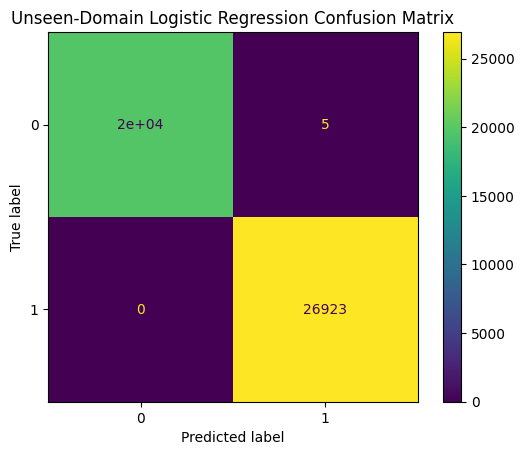

In [ ]:
# Logistic Regression report
print("\nUnseen-domain Logistic Regression classification report:")
print(classification_report(y_zero_test, zero_logistic_pred))

cm = confusion_matrix(y_zero_test, zero_logistic_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Unseen-Domain Logistic Regression Confusion Matrix")
plt.show()


Unseen-domain Random Forest classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19709
           1       1.00      1.00      1.00     26923

    accuracy                           1.00     46632
   macro avg       1.00      1.00      1.00     46632
weighted avg       1.00      1.00      1.00     46632



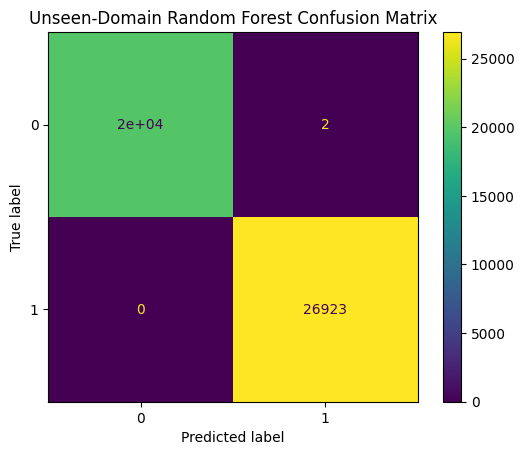

In [ ]:
# Random Forest report
print("\nUnseen-domain Random Forest classification report:")
print(classification_report(y_zero_test, zero_rf_pred))

cm = confusion_matrix(y_zero_test, zero_rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Unseen-Domain Random Forest Confusion Matrix")
plt.show()

In [ ]:
# Use the cleaned numeric dataset
robust_data = df.copy()
robust_numeric = robust_data.drop(columns=['URL', 'Domain', 'TLD', 'Title'])

In [ ]:
# Obfuscated URL samples
obfuscated_data = robust_numeric[robust_numeric['HasObfuscation'] == 1]

X_obfuscated = obfuscated_data.drop(columns=['label'])
y_obfuscated = obfuscated_data['label']

X_obfuscated_scaled = scaler.transform(X_obfuscated)
X_obfuscated_scaled = pd.DataFrame(X_obfuscated_scaled, columns=X.columns)

print("Obfuscated sample shape:", X_obfuscated.shape)
print("\nObfuscated sample class distribution:")
print(y_obfuscated.value_counts())

Obfuscated sample shape: (483, 50)

Obfuscated sample class distribution:
label
0    483
Name: count, dtype: int64


In [ ]:
# Random Forest on obfuscated samples
rf_obfuscated_pred = random_forest_model.predict(X_obfuscated_scaled)
rf_obfuscated_prob = random_forest_model.predict_proba(X_obfuscated_scaled)[:, 1]

# ANN/DNN on obfuscated samples
ann_obfuscated_prob = ann_model.predict(X_obfuscated_scaled).ravel()
ann_obfuscated_pred = (ann_obfuscated_prob >= 0.5).astype(int)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [ ]:
# Long URL samples
long_url_limit = robust_numeric['URLLength'].quantile(0.95)
long_url_data = robust_numeric[robust_numeric['URLLength'] >= long_url_limit]

X_long_url = long_url_data.drop(columns=['label'])
y_long_url = long_url_data['label']

X_long_url_scaled = scaler.transform(X_long_url)
X_long_url_scaled = pd.DataFrame(X_long_url_scaled, columns=X.columns)

In [ ]:
print("\nLong URL threshold:", long_url_limit)
print("Long URL sample shape:", X_long_url.shape)
print("\nLong URL sample class distribution:")
print(y_long_url.value_counts())


Long URL threshold: 73.0
Long URL sample shape: (11958, 50)

Long URL sample class distribution:
label
0    11958
Name: count, dtype: int64


In [ ]:
# Random Forest on long URL samples
rf_long_pred = random_forest_model.predict(X_long_url_scaled)
rf_long_prob = random_forest_model.predict_proba(X_long_url_scaled)[:, 1]

# ANN/DNN on long URL samples
ann_long_prob = ann_model.predict(X_long_url_scaled).ravel()
ann_long_pred = (ann_long_prob >= 0.5).astype(int)

374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
# Create noisy test data
X_test_noisy = X_test.copy()

In [ ]:
# Add simple noise to URL-related features
X_test_noisy['URLLength'] = X_test_noisy['URLLength'] + 10
X_test_noisy['NoOfLettersInURL'] = X_test_noisy['NoOfLettersInURL'] + 5
X_test_noisy['NoOfDegitsInURL'] = X_test_noisy['NoOfDegitsInURL'] + 3
X_test_noisy['NoOfOtherSpecialCharsInURL'] = X_test_noisy['NoOfOtherSpecialCharsInURL'] + 2
X_test_noisy['SpacialCharRatioInURL'] = X_test_noisy['SpacialCharRatioInURL'] + 0.02
X_test_noisy['DegitRatioInURL'] = X_test_noisy['DegitRatioInURL'] + 0.01
X_test_noisy['URLSimilarityIndex'] = X_test_noisy['URLSimilarityIndex'] - 2

In [ ]:
# Keep values within valid ranges where needed
X_test_noisy['SpacialCharRatioInURL'] = X_test_noisy['SpacialCharRatioInURL'].clip(0, 1)
X_test_noisy['DegitRatioInURL'] = X_test_noisy['DegitRatioInURL'].clip(0, 1)
X_test_noisy['URLSimilarityIndex'] = X_test_noisy['URLSimilarityIndex'].clip(0, 100)

X_test_noisy_scaled = scaler.transform(X_test_noisy)
X_test_noisy_scaled = pd.DataFrame(X_test_noisy_scaled, columns=X.columns)

print("\nNoisy test data shape:", X_test_noisy.shape)


Noisy test data shape: (47074, 50)


In [ ]:
# Random Forest on noisy test data
rf_noisy_pred = random_forest_model.predict(X_test_noisy_scaled)
rf_noisy_prob = random_forest_model.predict_proba(X_test_noisy_scaled)[:, 1]

# ANN/DNN on noisy test data
ann_noisy_prob = ann_model.predict(X_test_noisy_scaled).ravel()
ann_noisy_pred = (ann_noisy_prob >= 0.5).astype(int)

1472/1472 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [ ]:
# Create robustness results table
robustness_results = pd.DataFrame({
    'Test Type': [
        'Obfuscated URLs',
        'Obfuscated URLs',
        'Long URLs',
        'Long URLs',
        'Noisy Test Data',
        'Noisy Test Data'
    ],
    'Model': [
        'Random Forest',
        'ANN/DNN',
        'Random Forest',
        'ANN/DNN',
        'Random Forest',
        'ANN/DNN'
    ],
    'Accuracy': [
        accuracy_score(y_obfuscated, rf_obfuscated_pred),
        accuracy_score(y_obfuscated, ann_obfuscated_pred),
        accuracy_score(y_long_url, rf_long_pred),
        accuracy_score(y_long_url, ann_long_pred),
        accuracy_score(y_test, rf_noisy_pred),
        accuracy_score(y_test, ann_noisy_pred)
    ],
    'Precision Weighted': [
        precision_score(y_obfuscated, rf_obfuscated_pred, average='weighted', zero_division=0),
        precision_score(y_obfuscated, ann_obfuscated_pred, average='weighted', zero_division=0),
        precision_score(y_long_url, rf_long_pred, average='weighted', zero_division=0),
        precision_score(y_long_url, ann_long_pred, average='weighted', zero_division=0),
        precision_score(y_test, rf_noisy_pred, average='weighted', zero_division=0),
        precision_score(y_test, ann_noisy_pred, average='weighted', zero_division=0)
    ],
    'Recall Weighted': [
        recall_score(y_obfuscated, rf_obfuscated_pred, average='weighted', zero_division=0),
        recall_score(y_obfuscated, ann_obfuscated_pred, average='weighted', zero_division=0),
        recall_score(y_long_url, rf_long_pred, average='weighted', zero_division=0),
        recall_score(y_long_url, ann_long_pred, average='weighted', zero_division=0),
        recall_score(y_test, rf_noisy_pred, average='weighted', zero_division=0),
        recall_score(y_test, ann_noisy_pred, average='weighted', zero_division=0)
    ],
    'F1 Weighted': [
        f1_score(y_obfuscated, rf_obfuscated_pred, average='weighted', zero_division=0),
        f1_score(y_obfuscated, ann_obfuscated_pred, average='weighted', zero_division=0),
        f1_score(y_long_url, rf_long_pred, average='weighted', zero_division=0),
        f1_score(y_long_url, ann_long_pred, average='weighted', zero_division=0),
        f1_score(y_test, rf_noisy_pred, average='weighted', zero_division=0),
        f1_score(y_test, ann_noisy_pred, average='weighted', zero_division=0)
    ],
    'Phishing Recall Class 0': [
        recall_score(y_obfuscated, rf_obfuscated_pred, pos_label=0, zero_division=0),
        recall_score(y_obfuscated, ann_obfuscated_pred, pos_label=0, zero_division=0),
        recall_score(y_long_url, rf_long_pred, pos_label=0, zero_division=0),
        recall_score(y_long_url, ann_long_pred, pos_label=0, zero_division=0),
        recall_score(y_test, rf_noisy_pred, pos_label=0, zero_division=0),
        recall_score(y_test, ann_noisy_pred, pos_label=0, zero_division=0)
    ],
    'Phishing F1 Class 0': [
        f1_score(y_obfuscated, rf_obfuscated_pred, pos_label=0, zero_division=0),
        f1_score(y_obfuscated, ann_obfuscated_pred, pos_label=0, zero_division=0),
        f1_score(y_long_url, rf_long_pred, pos_label=0, zero_division=0),
        f1_score(y_long_url, ann_long_pred, pos_label=0, zero_division=0),
        f1_score(y_test, rf_noisy_pred, pos_label=0, zero_division=0),
        f1_score(y_test, ann_noisy_pred, pos_label=0, zero_division=0)
    ]
})

print("\nRobustness testing results:")
display(robustness_results)


Robustness testing results:


,Test Type,Model,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,Phishing Recall Class 0,Phishing F1 Class 0
0,Obfuscated URLs,Random Forest,1.00000,1.00000,1.00000,1.00000,1.0,1.000000
1,Obfuscated URLs,ANN/DNN,1.00000,1.00000,1.00000,1.00000,1.0,1.000000
2,Long URLs,Random Forest,1.00000,1.00000,1.00000,1.00000,1.0,1.000000
3,Long URLs,ANN/DNN,1.00000,1.00000,1.00000,1.00000,1.0,1.000000
4,Noisy Test Data,Random Forest,0.99966,0.99966,0.99966,0.99966,1.0,0.999602
5,Noisy Test Data,ANN/DNN,0.99983,0.99983,0.99983,0.99983,1.0,0.999801



Random Forest noisy data classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20104
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



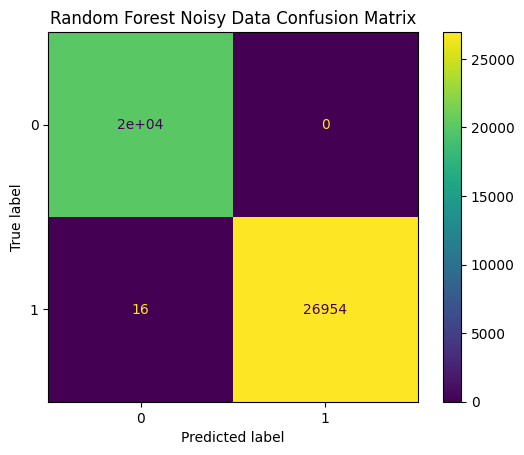

In [ ]:
# Confusion matrix for noisy Random Forest
print("\nRandom Forest noisy data classification report:")
print(classification_report(y_test, rf_noisy_pred, zero_division=0))

cm = confusion_matrix(y_test, rf_noisy_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Random Forest Noisy Data Confusion Matrix")
plt.show()


ANN/DNN noisy data classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20104
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



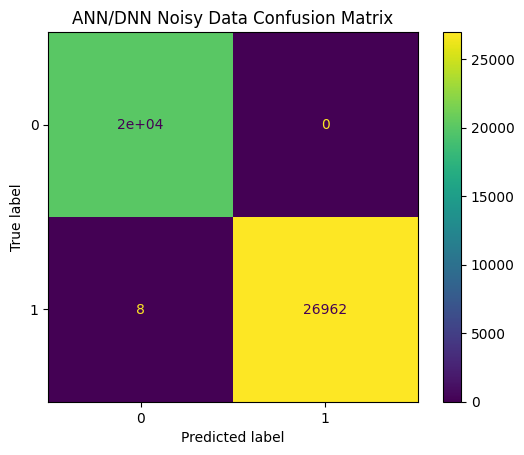

In [ ]:
# Confusion matrix for noisy ANN/DNN
print("\nANN/DNN noisy data classification report:")
print(classification_report(y_test, ann_noisy_pred, zero_division=0))

cm = confusion_matrix(y_test, ann_noisy_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("ANN/DNN Noisy Data Confusion Matrix")
plt.show()

In [ ]:
# Random Forest feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print("Top 20 Random Forest important features:")
display(feature_importance.head(20))

Top 20 Random Forest important features:


,Feature,Importance
3,URLSimilarityIndex,0.190016
49,NoOfExternalRef,0.170563
22,LineOfCode,0.147818
47,NoOfSelfRef,0.107939
44,NoOfImage,0.081970
46,NoOfJS,0.069487
36,HasSocialNet,0.032353
45,NoOfCSS,0.030072
43,HasCopyrightInfo,0.024645
21,IsHTTPS,0.022375


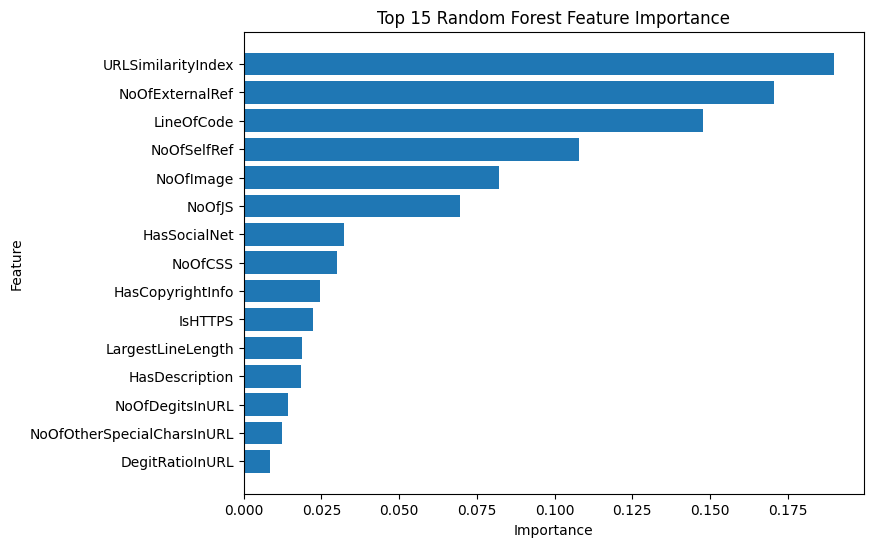

In [ ]:
plt.figure(figsize=(8, 6))
plt.barh(feature_importance.head(15)['Feature'][::-1], feature_importance.head(15)['Importance'][::-1])
plt.title('Top 15 Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
# Select small sample for SHAP
X_shap = X_test_scaled.sample(n=500, random_state=42)

# SHAP explanation for Random Forest
explainer = shap.TreeExplainer(random_forest_model)
shap_values = explainer.shap_values(X_shap)

# Select SHAP values for class 0 phishing
if isinstance(shap_values, list):
    shap_values_class0 = shap_values[0]
else:
    shap_values_class0 = shap_values[:, :, 0]

In [ ]:
# Mean SHAP importance
shap_importance = pd.DataFrame({
    'Feature': X_shap.columns,
    'Mean Absolute SHAP Value': np.abs(shap_values_class0).mean(axis=0)
})

shap_importance = shap_importance.sort_values(by='Mean Absolute SHAP Value', ascending=False)

print("\nTop 20 SHAP important features for phishing class 0:")
display(shap_importance.head(20))


Top 20 SHAP important features for phishing class 0:


,Feature,Mean Absolute SHAP Value
3,URLSimilarityIndex,0.172452
22,LineOfCode,0.066841
49,NoOfExternalRef,0.048709
47,NoOfSelfRef,0.040734
21,IsHTTPS,0.034185
44,NoOfImage,0.031329
46,NoOfJS,0.019015
36,HasSocialNet,0.016802
43,HasCopyrightInfo,0.011002
45,NoOfCSS,0.010086


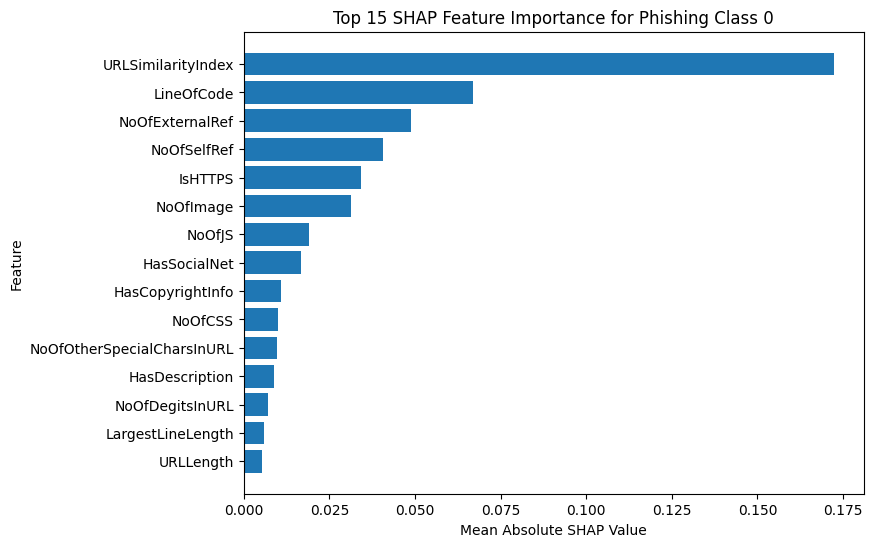

In [ ]:
plt.figure(figsize=(8, 6))
plt.barh(shap_importance.head(15)['Feature'][::-1], shap_importance.head(15)['Mean Absolute SHAP Value'][::-1])
plt.title('Top 15 SHAP Feature Importance for Phishing Class 0')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.show()

/tmp/ipykernel_16306/1700776519.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_class0, X_shap, max_display=15)


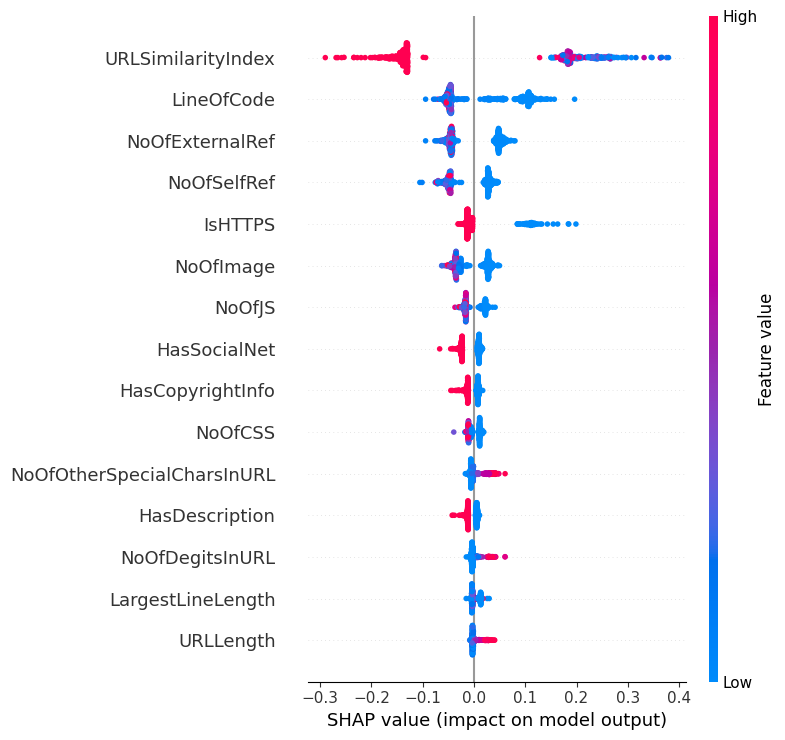

In [ ]:
# SHAP summary plot
shap.summary_plot(shap_values_class0, X_shap, max_display=15)

In [ ]:
# Prepare local examples
test_results = X_test_scaled.copy()
test_results['Actual'] = y_test.values
test_results['Predicted'] = random_forest_pred

phishing_row = X_test_scaled[test_results['Actual'] == 0].iloc[[0]]
legitimate_row = X_test_scaled[test_results['Actual'] == 1].iloc[[0]]

local_data = pd.concat([phishing_row, legitimate_row])

local_shap_values = explainer.shap_values(local_data)

if isinstance(local_shap_values, list):
    local_shap_values_class0 = local_shap_values[0]
else:
    local_shap_values_class0 = local_shap_values[:, :, 0]

In [ ]:
# Local explanation for one phishing sample
phishing_explanation = pd.DataFrame({
    'Feature': local_data.columns,
    'SHAP Value': local_shap_values_class0[0],
    'Feature Value': phishing_row.iloc[0].values
})

phishing_explanation['Absolute SHAP Value'] = phishing_explanation['SHAP Value'].abs()
phishing_explanation = phishing_explanation.sort_values(by='Absolute SHAP Value', ascending=False)

print("\nLocal SHAP explanation for one phishing sample:")
display(phishing_explanation.head(10))


Local SHAP explanation for one phishing sample:


,Feature,SHAP Value,Feature Value,Absolute SHAP Value
3,URLSimilarityIndex,0.257816,-1.411981,0.257816
49,NoOfExternalRef,0.053272,-0.300931,0.053272
22,LineOfCode,0.050218,-0.290245,0.050218
14,NoOfDegitsInURL,0.045161,1.030895,0.045161
47,NoOfSelfRef,0.037449,-0.390412,0.037449
44,NoOfImage,0.035833,-0.340123,0.035833
46,NoOfJS,0.027871,-0.447097,0.027871
15,DegitRatioInURL,0.018261,5.336195,0.018261
45,NoOfCSS,0.016922,-0.076468,0.016922
36,HasSocialNet,0.014923,-0.918418,0.014923


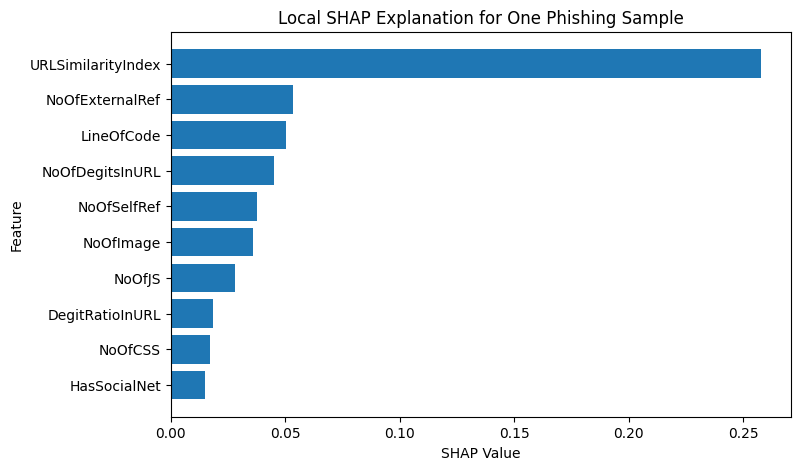

In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(phishing_explanation.head(10)['Feature'][::-1], phishing_explanation.head(10)['SHAP Value'][::-1])
plt.title('Local SHAP Explanation for One Phishing Sample')
plt.xlabel('SHAP Value')
plt.ylabel('Feature')
plt.show()

In [ ]:
# Local explanation for one legitimate sample
legitimate_explanation = pd.DataFrame({
    'Feature': local_data.columns,
    'SHAP Value': local_shap_values_class0[1],
    'Feature Value': legitimate_row.iloc[0].values
})

legitimate_explanation['Absolute SHAP Value'] = legitimate_explanation['SHAP Value'].abs()
legitimate_explanation = legitimate_explanation.sort_values(by='Absolute SHAP Value', ascending=False)

print("\nLocal SHAP explanation for one legitimate sample:")
display(legitimate_explanation.head(10))


Local SHAP explanation for one legitimate sample:


,Feature,SHAP Value,Feature Value,Absolute SHAP Value
3,URLSimilarityIndex,-0.150149,0.742656,0.150149
47,NoOfSelfRef,-0.062356,0.311269,0.062356
22,LineOfCode,-0.054626,-0.057519,0.054626
49,NoOfExternalRef,-0.052646,0.460305,0.052646
44,NoOfImage,-0.045342,0.078574,0.045342
46,NoOfJS,-0.018946,0.019214,0.018946
21,IsHTTPS,-0.015360,0.527162,0.015360
19,NoOfOtherSpecialCharsInURL,-0.008366,-0.365430,0.008366
25,DomainTitleMatchScore,-0.008233,1.003131,0.008233
36,HasSocialNet,0.008105,-0.918418,0.008105


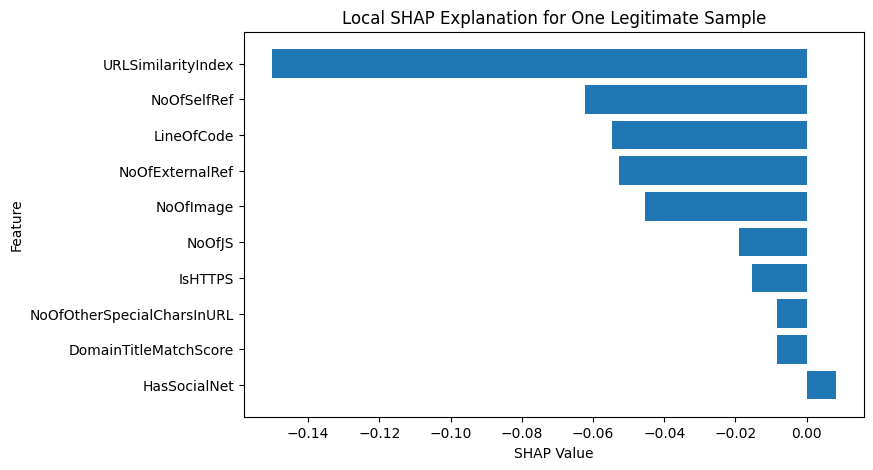

In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(legitimate_explanation.head(10)['Feature'][::-1], legitimate_explanation.head(10)['SHAP Value'][::-1])
plt.title('Local SHAP Explanation for One Legitimate Sample')
plt.xlabel('SHAP Value')
plt.ylabel('Feature')
plt.show()

In [ ]:
# Create dataset summary table
dataset_summary = pd.DataFrame({
    'Item': [
        'Original records',
        'Records after duplicate URL removal',
        'Total columns in original dataset',
        'Features used for modelling',
        'Text columns removed',
        'Class 0 records',
        'Class 1 records',
        'Class 0 percentage',
        'Class 1 percentage'
    ],
    'Value': [
        235795,
        df.shape[0],
        55,
        X.shape[1],
        4,
        df['label'].value_counts().sort_index().iloc[0],
        df['label'].value_counts().sort_index().iloc[1],
        round(df['label'].value_counts(normalize=True).sort_index().iloc[0] * 100, 2),
        round(df['label'].value_counts(normalize=True).sort_index().iloc[1] * 100, 2)
    ]
})

print("Dataset summary table:")
display(dataset_summary)

Dataset summary table:


,Item,Value
0,Original records,235795.00
1,Records after duplicate URL removal,235370.00
2,Total columns in original dataset,55.00
3,Features used for modelling,50.00
4,Text columns removed,4.00
5,Class 0 records,100520.00
6,Class 1 records,134850.00
7,Class 0 percentage,42.71
8,Class 1 percentage,57.29


In [ ]:
# Prepare normal model results
normal_results = all_model_results.copy()
normal_results.insert(0, 'Experiment', 'Normal Train-Test Split')

# Prepare unseen-domain results
zero_results = zero_hour_results.copy()
zero_results.insert(0, 'Experiment', 'Unseen-Domain Zero-Hour Simulation')

# Prepare robustness results
robust_results = robustness_results.copy()
robust_results = robust_results.rename(columns={'Test Type': 'Experiment'})
robust_results['ROC AUC'] = np.nan

In [ ]:
# Align columns
common_columns = [
    'Experiment',
    'Model',
    'Accuracy',
    'Precision Weighted',
    'Recall Weighted',
    'F1 Weighted',
    'ROC AUC',
    'Phishing Recall Class 0',
    'Phishing F1 Class 0'
]

normal_results = normal_results[common_columns]
zero_results = zero_results[common_columns]
robust_results = robust_results[common_columns]

In [ ]:
# Combine all result tables
final_results_table = pd.concat(
    [normal_results, zero_results, robust_results],
    ignore_index=True
)

print("\nFinal combined results table:")
display(final_results_table)


Final combined results table:


,Experiment,Model,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,ROC AUC,Phishing Recall Class 0,Phishing F1 Class 0
0,Normal Train-Test Split,Logistic Regression,0.999936,0.999936,0.999936,0.999936,1.000000,0.999851,0.999925
1,Normal Train-Test Split,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,Normal Train-Test Split,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,Normal Train-Test Split,Linear SVM,0.999958,0.999958,0.999958,0.999958,1.000000,0.999901,0.999950
4,Normal Train-Test Split,ANN/DNN,0.999958,0.999958,0.999958,0.999958,1.000000,0.999901,0.999950
5,Unseen-Domain Zero-Hour Simulation,Logistic Regression Unseen-Domain,0.999893,0.999893,0.999893,0.999893,0.999997,0.999746,0.999873
6,Unseen-Domain Zero-Hour Simulation,Random Forest Unseen-Domain,0.999957,0.999957,0.999957,0.999957,1.000000,0.999899,0.999949
7,Obfuscated URLs,Random Forest,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,1.000000
8,Obfuscated URLs,ANN/DNN,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,1.000000
9,Long URLs,Random Forest,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,1.000000


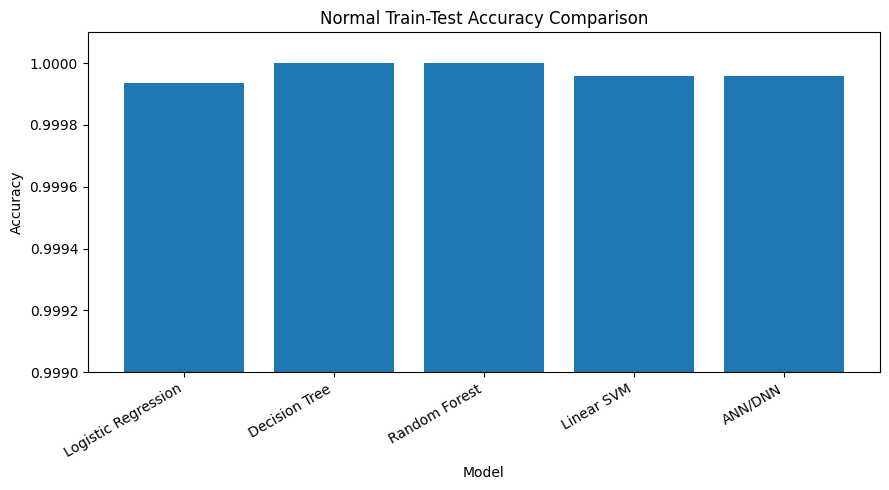

In [ ]:
# Normal model accuracy comparison
normal_plot = all_model_results[['Model', 'Accuracy', 'F1 Weighted']].copy()

plt.figure(figsize=(9, 5))
plt.bar(normal_plot['Model'], normal_plot['Accuracy'])
plt.title('Normal Train-Test Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=30, ha='right')
plt.ylim(0.999, 1.0001)
plt.tight_layout()
plt.show()

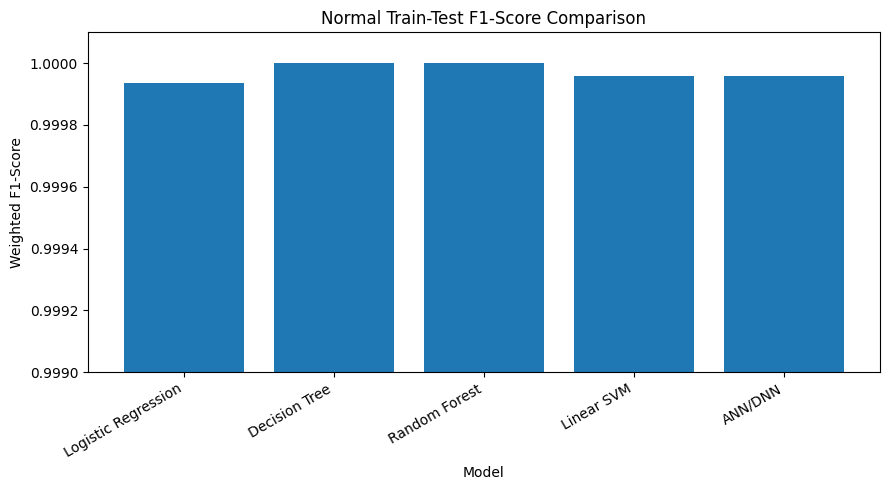

In [ ]:
# Normal model F1 comparison
plt.figure(figsize=(9, 5))
plt.bar(normal_plot['Model'], normal_plot['F1 Weighted'])
plt.title('Normal Train-Test F1-Score Comparison')
plt.xlabel('Model')
plt.ylabel('Weighted F1-Score')
plt.xticks(rotation=30, ha='right')
plt.ylim(0.999, 1.0001)
plt.tight_layout()
plt.show()

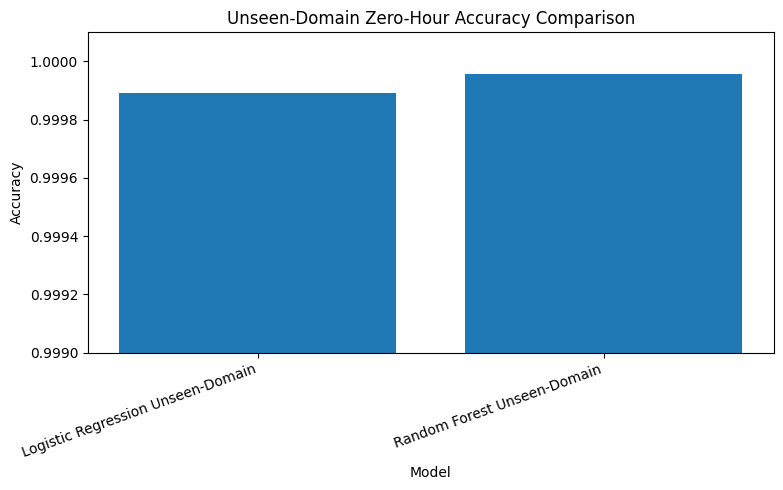

In [ ]:
# Unseen-domain accuracy comparison
zero_plot = zero_hour_results[['Model', 'Accuracy', 'F1 Weighted']].copy()

plt.figure(figsize=(8, 5))
plt.bar(zero_plot['Model'], zero_plot['Accuracy'])
plt.title('Unseen-Domain Zero-Hour Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=20, ha='right')
plt.ylim(0.999, 1.0001)
plt.tight_layout()
plt.show()

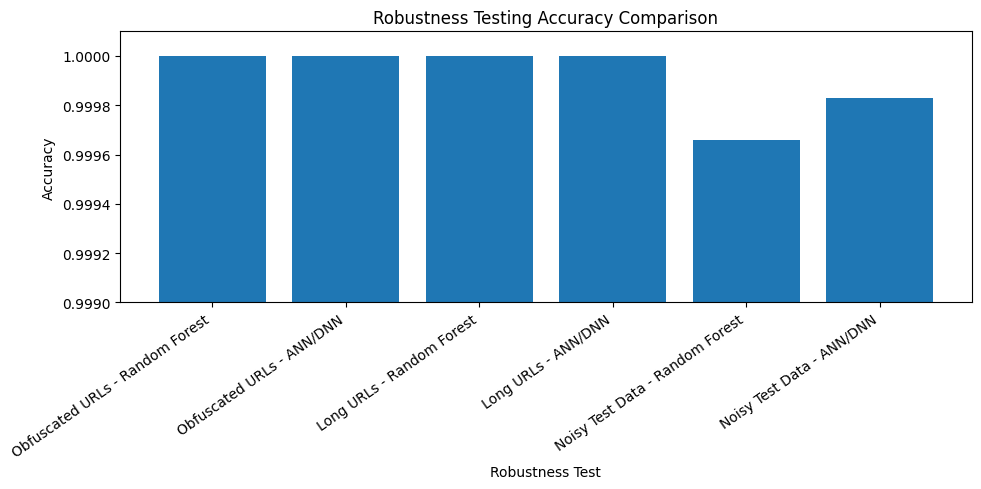

In [ ]:
# Robustness accuracy comparison
robust_plot = robustness_results[['Test Type', 'Model', 'Accuracy']].copy()
robust_plot['Label'] = robust_plot['Test Type'] + ' - ' + robust_plot['Model']

plt.figure(figsize=(10, 5))
plt.bar(robust_plot['Label'], robust_plot['Accuracy'])
plt.title('Robustness Testing Accuracy Comparison')
plt.xlabel('Robustness Test')
plt.ylabel('Accuracy')
plt.xticks(rotation=35, ha='right')
plt.ylim(0.999, 1.0001)
plt.tight_layout()
plt.show()

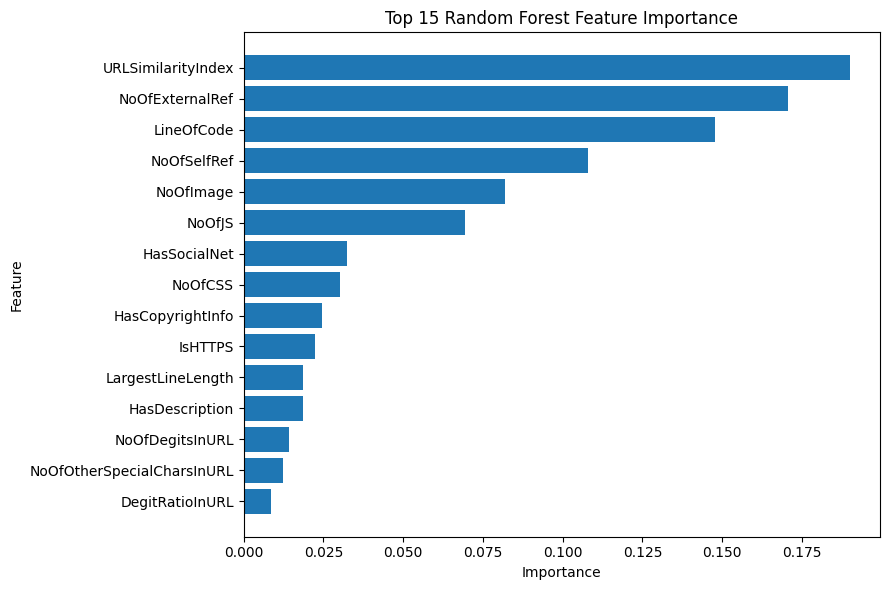

In [ ]:
# Top Random Forest feature importance graph
top_rf_features = feature_importance.head(15).copy()

plt.figure(figsize=(9, 6))
plt.barh(top_rf_features['Feature'][::-1], top_rf_features['Importance'][::-1])
plt.title('Top 15 Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

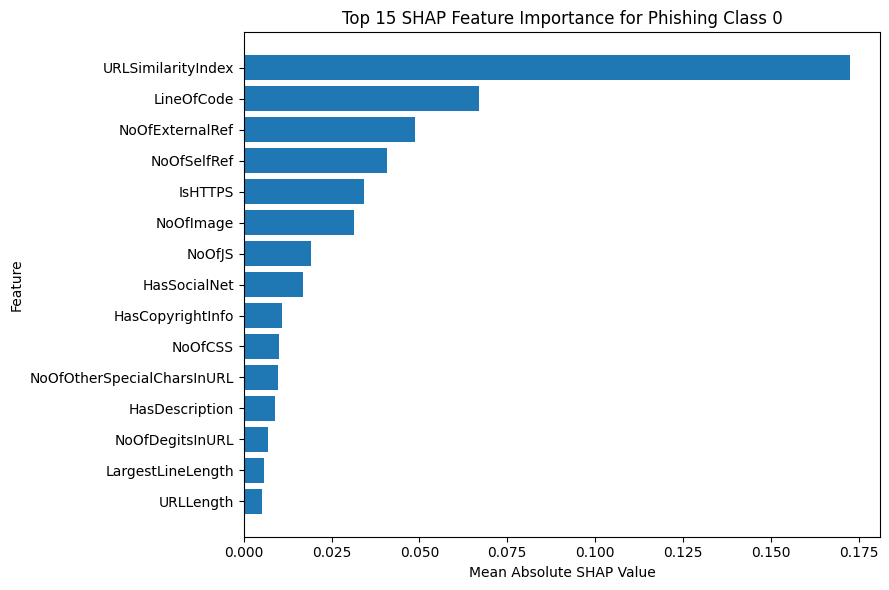

In [ ]:
# Top SHAP feature importance graph
top_shap_features = shap_importance.head(15).copy()

plt.figure(figsize=(9, 6))
plt.barh(top_shap_features['Feature'][::-1], top_shap_features['Mean Absolute SHAP Value'][::-1])
plt.title('Top 15 SHAP Feature Importance for Phishing Class 0')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()